In [77]:
import matplotlib
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
import matplotlib.gridspec as gridspec
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

In [3]:
def setup_graph():
    plt.xlim(-1, 8)
    plt.ylim(-1, 2)
    plt.xticks(range(8))
    plt.yticks([0, 1])
    plt.axhline(0, color="black", ls="--")
    plt.axvline(0, color="black", ls="--")

def configure_axes(ax):
    ax.axhline(color="black", ls="--")
    ax.axvline(color="black", ls="--")
    ax.set_xlim(-2, 5)
    ax.set_ylim(-1, 8)

# Save a figure to a file
def save_fig(fig, file_path,):
    # COMMENT OUT THIS LINE TO DISABLE SAVING
    fig.savefig(file_path, bbox_inches="tight")
    pass

import os
image_folder_name="generated_images"
os.makedirs(image_folder_name, exist_ok=True)

x = 3.5, f(x) = 2.5833333333333335
f'(x) = 1.6666666666666667


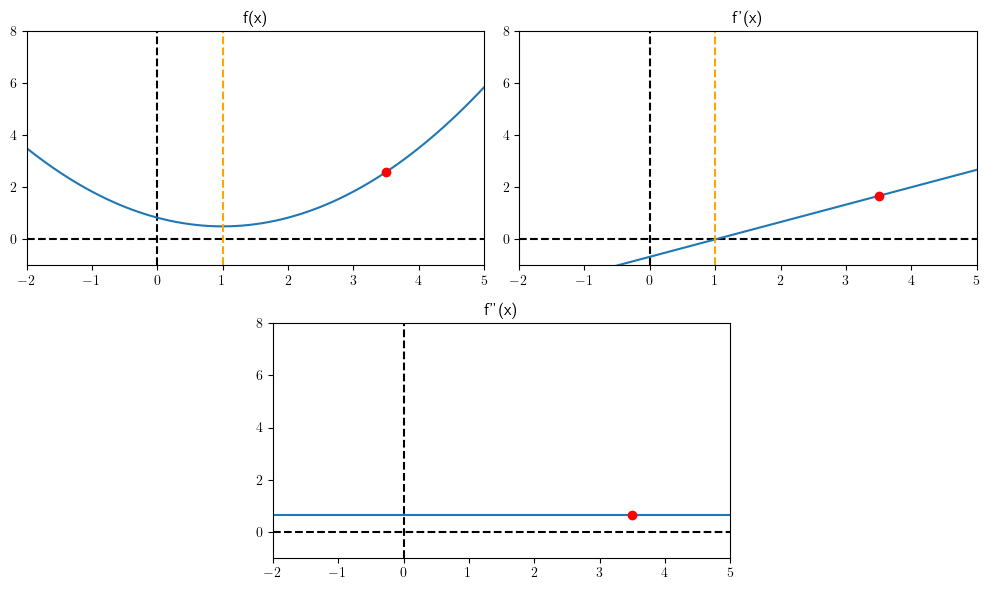

In [19]:
xs = [x/10 for x in range(-100, 100)]
ys= [((x-1)**2) /3 + 0.5 for x in xs]

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3]) 
configure_axes(ax1)
configure_axes(ax2)
configure_axes(ax3)

ax1.set_title("f(x)")
ax1.plot(xs, ys)
ax1.axvline(1, color="orange", ls="--")
ax1.plot(xs[-65], ys[-65], "ro-")
print(f"x = {xs[-65]}, f(x) = {ys[-65]}")

ax2.set_title("f'(x)")
ax2.plot(xs, [2*(x-1)/3 for x in xs])
y_val = 2*(xs[-65]-1)/3
ax2.plot(xs[-65], [y_val], "ro-")
ax2.axvline(1, color="orange", ls="--")
print(f"f'(x) = {y_val}")

ax3.set_title("f''(x)")
ax3.plot(xs, [2/3 for _ in xs])
ax3.plot(xs[-65], 2/3, "ro-")
plt.tight_layout()

save_fig(fig, f"{image_folder_name}/simple_quadratic.png")

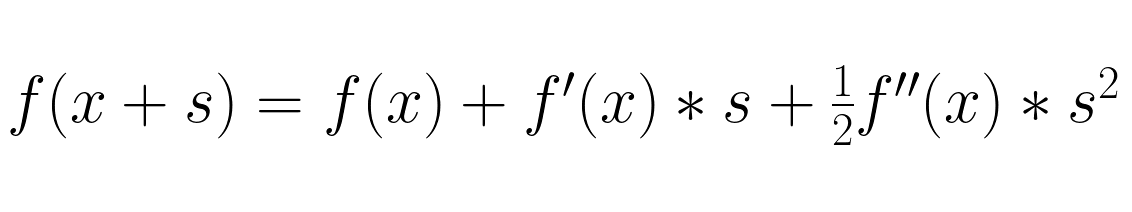

In [20]:
taylor_string = r"$f(x + s) = f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2$"

fig = plt.figure(figsize=(10, 2.5))  # Dimensions of figsize are in inches
plt.gca().axis("off")
fig.text(
    x=0.5,  # x-coordinate to place the text
    y=0.5,  # y-coordinate to place the text
    s=taylor_string,
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=48,
)
save_fig(fig, f"{image_folder_name}/second_taylor.png")

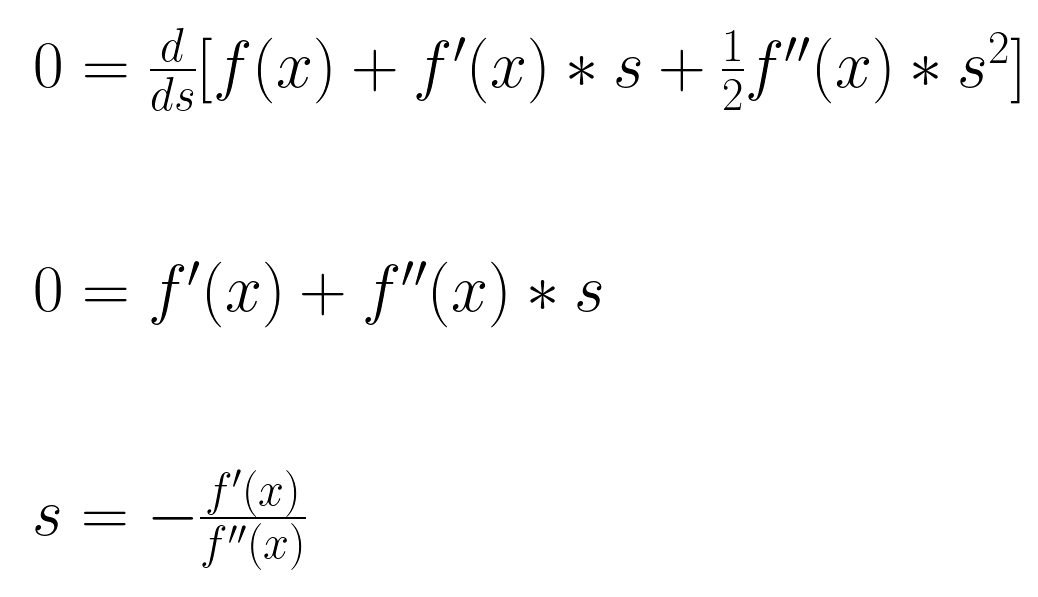

In [21]:
eq_1 = r"$0 = \frac{d}{ds}[f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2]$"
eq_2 = r"$0 = f'(x) + f''(x) * s$"
eq_3 = r"$s = -\frac{f'(x)}{f''(x)}$"

equations = [eq_1, eq_2, eq_3]

fig = plt.figure(figsize=(10, 7.5))
plt.gca().axis("off")
for (i, eq) in enumerate(equations):
        fig.text(
            x = 0.15,
            y= 0.8 - 0.3 * i,
            s=eq,
            horizontalalignment="left",
            verticalalignment="center",
            fontsize=48
        )
save_fig(fig, f"{image_folder_name}/step_calculation.png")

---

## Manim: 3D scaffold

Minimal starting point — a sloped plane in 3D — to build the optimizer animation from.
Run the config cell once, then the scene cell renders and embeds the video inline.

A few things to know as you experiment:
- Uses the **default Cairo renderer** (renders reliably in the notebook). The OpenGL
  renderer gives true depth but won't render to a movie headlessly on macOS, so avoid it here.
- To draw math equations you'll need `MathTex`, which shells out to LaTeX (installed).
- Docs: https://docs.manim.community/ — the Surface, ThreeDScene, and ThreeDAxes references
  are the relevant ones for this scene.

In [4]:
from manim import *
import numpy as np

# Inline preview size in the notebook.
config.media_width = "80%"
config.media_embed = True


In [ ]:
%%manim -ql -v WARNING DescentComparison
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...


starting_point = [-0.5, 1.4]

def surface_function(p):
    x, y = p
    return  x**2 + 0.8*y**2 + 0.1 * torch.cos(2*x) + 0.1 * torch.sin(2*y) + 0.5 * torch.sin(5*x) + 0.5 * torch.cos(5*y)

positions_g = []

def record_position(p):
    positions_g.append([*p.detach().tolist(), surface_function(p).item()])

# STARTING POSITION
p = torch.tensor([-0.5, 1.4], requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.1)

record_position(p)

for _ in range(200):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p)

print(positions_g[0:5])
print(positions_g[-5:])

class DescentComparison(ThreeDScene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        axes = ThreeDAxes(x_range=[-3, 3, 1], y_range=[-3, 3, 1], z_range=[-3, 3, 1])

        gradient_coords = [axes.c2p(x, y, z+0.4) for (x, y, z) in positions_g]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)

        # A Surface is defined by a function (u, v) -> a point in space.
        # axes.c2p ("coords to point") maps math coordinates onto the axes,
        # so the surface lines up with the frame. Here z is a linear slope.
        
        def scene_surface(x, y):
            p = torch.tensor([x,y], requires_grad=False)
            z = float(surface_function(p))
            return axes.c2p(x, y, z)

        surface = Surface(
            scene_surface,
            u_range=[-2, 2],
            v_range=[-2, 2],
            resolution=(16, 16),  # grid density: higher = smoother but slower
        )

        dot = Dot3D(point=gradient_coords[0], color=RED)

        # Point the camera. phi = tilt down from vertical, theta = spin around.
        self.set_camera_orientation(phi=25 * DEGREES, theta=-45 * DEGREES)
        # self.begin_ambient_camera_rotation()

        # add() puts something on screen instantly; play() animates it.
        self.add(axes)
        # self.play(Create(axes))
        # self.wait()
        self.play(Create(surface))
        # self.add(surface)
        # self.play(Create(dot))
        self.add(dot)
        # self.play(Create(gradient_path))
        trace = TracedPath(dot.get_center)
        self.add(trace)
        self.play(MoveAlongPath(dot, gradient_path, rate_func = rate_functions.ease_in_out_expo, run_time=3))
        self.wait()

[[-0.5, 1.399999976158142, 1.9832439422607422], [-0.2165435254573822, 1.35909104347229, 1.6506481170654297], [-0.2988607585430145, 1.2824095487594604, 1.5394879579544067], [-0.26944831013679504, 1.126115083694458, 1.1602981090545654], [-0.28124678134918213, 0.8067192435264587, -0.022933602333068848]]
[[-0.27793487906455994, 0.5487039089202881, -0.4606703519821167], [-0.27793484926223755, 0.5487039089202881, -0.4606703221797943], [-0.27793487906455994, 0.5487039089202881, -0.4606703519821167], [-0.27793484926223755, 0.5487039089202881, -0.4606703221797943], [-0.27793487906455994, 0.5487039089202881, -0.4606703519821167]]


Manim Community v0.20.1

In [65]:
%%manim -ql -v WARNING PolygramExample

import numpy as np

class PolygramExample(Scene):
    def construct(self):
        hexagram = Polygram(
            [[0, 2, 0], [-np.sqrt(3), -1, 0], [np.sqrt(3), -1, 0]],
            [[-np.sqrt(3), 1, 0], [0, -2, 0], [np.sqrt(3), 1, 0]],
        )
        self.add(hexagram)

        dot = Dot()
        self.play(MoveAlongPath(dot, hexagram), run_time=5, rate_func=linear)
        self.remove(dot)
        self.wait()

Manim Community v0.20.1